# Planner Model 
This is the 1D subproblem from Optimal (Un)Conventional Monetary Policy (Andrey Alexandrov and Markus K. Brunnermeier). 
The original numerical method needs to solve this 1D subproblem to setup the 3D solution. 
With neural networks, we don't need to explicitly solve this subproblem. This file is to provide a basic converted python version of the numerical code. 

## Model setup

There are exogenous aggregate risk
$$
d\tilde{\sigma}_t^2 = \mu_s(\tilde{\sigma}_t^2)\,dt + \sigma_s(\tilde{\sigma}_t^2)\,dZ_t,
\qquad
\mu_s = -b_s\left(\tilde{\sigma}_t^2 - \tilde{\sigma}_{ss}^2\right),
\quad
\sigma_s = \nu_s \left(\tilde{\sigma}_t^2\right)^{s_{pp}/2}.
$$

Assume the following functional forms of investment technology, deposit convenience and transaction-cost slope
$$
\begin{align*}
\Phi(\iota) &= \tfrac{1}{\phi}\log(1+\phi\iota),
&
b(\upsilon) &= \tfrac{b}{2}(\upsilon^2-1),
&
b'(\upsilon) &= b\upsilon,\\
t(\nu) &= c_\nu\left(\nu/\nu_b\right)^{c_p},
&
t'(\nu) &= c_\nu c_p \nu^{c_p-1}/\nu_b^{c_p}.
\end{align*}
$$
with $b = a(1+\rho\phi)/[\rho(1+a\phi)(1-\lambda)]$ and $\lambda=\lambda_H/(\lambda_I+\lambda_H)$.

Given the current realization of $\tilde{\sigma}^2$, the planner chooses optimal allocation $\eta$. Let $\lambda=\frac{\lambda_H}{\lambda_I+\lambda_H}$. For every $x=\tilde{\sigma}^2$, we compute:
$$
\begin{align*}
\gamma &= \left( \frac{(1-\lambda)(\rho(1-\eta) + \lambda_I)}{\rho(1-\eta)^2} - \frac{\lambda(\rho \eta + \lambda_H)}{\rho \eta^2} \right) \frac{(1-\lambda) \eta^2 + \lambda \varphi^2 (1-\eta)^2}{(1-\lambda) \eta - \lambda \varphi^2(1-\eta)}\\
\theta &= \frac{\gamma}{1+\gamma}(1+\rho\phi)
\end{align*}
$$

Then we solve for $\eta$, by eq120 in the paper
$$
\gamma = \frac{1}{\rho} \frac{\lambda(1-\lambda)\varphi^2(1-\theta)^2}{(1-\lambda) \eta^2 + \lambda \varphi^2 (1-\eta)^2} \tilde{\sigma}^2
$$

The drift and diffusion coefficients of $\eta$ and $\theta$ can be computed with Ito's lemma and autodifferentiation.

In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.func import jacrev, hessian, vmap
from deep_macrofin import PDEModel
from deep_macrofin import OptimizerType, set_seeds

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "./models/planner"

# IRF / grid settings
Nsp = 2001
dZ = 1.0
T_irf = 40.0
dt_irf = 0.01
ap = 5.0  # pre-shock window length

params = {
    "rho": 0.07,       # discount rate
    "a": 0.18,         # productivity
    "delta": 0.01,     # depreciation
    "phi": 5.0,        # investment adjustment
    "bs": 0.15,        # mean reversion of \tilde{sigma}^2
    "sig2_ss": 0.5,    # steady-state idiosyncratic risk
    "nus": 0.02,       # diffusion of \tilde{sigma}^2
    "varphi": 0.3,     # relative idiosyncratic loading
    "spp": 1.0,
    "lam_I": 0.18 * 0.001,  # type switch
    "sig2_min": 0.8,
    "sig2_max": 1.2,
}
params["lam_H"] = params["lam_I"] / 9.0
params["lam"] = params["lam_H"] / (params["lam_I"] + params["lam_H"])
params["b"] = (
    params["a"]
    * (1 + params["rho"] * params["phi"])
    / (params["rho"] * (1 + params["a"] * params["phi"]) * (1 - params["lam"]))
)
# Planner FOC for upsilon has root u*=1 under this parameterization
params["u"] = 1.0

In [3]:
def compute_gamma(eta, rho, lam_I, lam_H, lam, varphi):
    term1 = (1 - lam) * (rho * (1 - eta) + lam_I) / (rho * (1 - eta) ** 2)
    term2 = lam * (rho * eta + lam_H) / (rho * eta ** 2)
    term3 = (
        eta ** 2 * (1 - lam) + (1 - eta) ** 2 * lam * varphi ** 2
    ) / (
        eta * (1 - lam) - (1 - eta) * lam * varphi ** 2
    )
    return (term1 - term2) * term3

def compute_theta(gamma, rho, phi):
    return gamma / (1 + gamma) * (1 + rho * phi)

def compute_endog_foc(sig2, lam, varphi, eta, gamma, rho, theta):
    term = (
        lam * (1 - lam) * varphi ** 2
    ) / (
        eta ** 2 * (1 - lam) + (1 - eta) ** 2 * lam * varphi ** 2
    )
    return gamma - (1 / rho) * (1 - theta) ** 2 * sig2 * term

def compute_iota(theta, a, u, rho, phi):
    return ((1 - theta) * a * u - rho) / (1 - theta + rho * phi)

def compute_chi(eta, lam, varphi):
    return (
        (1 - lam) * eta ** 2
        / ((1 - lam) * eta ** 2 + lam * varphi ** 2 * (1 - eta) ** 2)
    )

def compute_Phi(iota, phi):
    return (1.0 / phi) * torch.log(1.0 + phi * iota)

# AD through theta(sig2) = theta(gamma(eta(sig2)))
def compute_theta_sv(SV, compute_eta, rho, lam_I, lam_H, lam, varphi, phi):
    eta = compute_eta(SV)
    gamma = compute_gamma(eta, rho, lam_I, lam_H, lam, varphi)
    return compute_theta(gamma, rho, phi)

def compute_dtheta(SV, compute_eta, rho, lam_I, lam_H, lam, varphi, phi, compute_theta_sv):
    return vmap(
        jacrev(lambda sv: compute_theta_sv(
            sv.unsqueeze(0), compute_eta, rho, lam_I, lam_H, lam, varphi, phi
        ).squeeze(0))
    )(SV)

def compute_d2theta(SV, compute_eta, rho, lam_I, lam_H, lam, varphi, phi, compute_theta_sv):
    return vmap(
        hessian(lambda sv: compute_theta_sv(
            sv.unsqueeze(0), compute_eta, rho, lam_I, lam_H, lam, varphi, phi
        ).squeeze(0))
    )(SV)

def compute_mu_eta(eta, eta_Jac, eta_Hess, sig2, bs, sig2_ss, nus, spp):
    deta = eta_Jac[:, 0, 0:1]
    ddeta = eta_Hess[:, 0, 0, 0:1]
    return (deta * bs * (sig2_ss - sig2) + 0.5 * ddeta * nus ** 2 * sig2 ** spp) / eta

def compute_sig_eta(eta, eta_Jac, sig2, nus, spp):
    deta = eta_Jac[:, 0, 0:1]
    return deta * nus * torch.sqrt(sig2) ** spp / eta

def compute_mu_theta(theta, dtheta, d2theta, sig2, bs, sig2_ss, nus, spp):
    dt = dtheta[:, 0, 0:1]
    ddt = d2theta[:, 0, 0, 0:1]
    return (dt * bs * (sig2_ss - sig2) + 0.5 * ddt * nus ** 2 * sig2 ** spp) / theta

def compute_sig_theta(theta, dtheta, sig2, nus, spp):
    dt = dtheta[:, 0, 0:1]
    return dt * nus * torch.sqrt(sig2) ** spp / theta

def get_model(model_path: str, params: dict, model_size: list[int]):
    set_seeds(42)
    model = PDEModel("planner",
        config={
            "batch_size": 500,
            "num_epochs": 1000,
            "optimizer_type": OptimizerType.Adam,
            "lr": 1e-3,
        },
    )
    model.set_state(
        ["sig2"],
        {"sig2": [params["sig2_ss"] * params["sig2_min"], params["sig2_ss"] * params["sig2_max"]]},
    )
    model.add_params(params)
    model.add_endog("eta", config={"hidden_units": model_size, "batch_jac_hes": True, "positive": True})
    model.register_functions([
        compute_gamma, compute_theta, compute_endog_foc,
        compute_iota, compute_chi, compute_Phi,
        compute_theta_sv, compute_dtheta, compute_d2theta,
        compute_mu_eta, compute_sig_eta, compute_mu_theta, compute_sig_theta,
    ])
    model.add_equations([
        "gamma=compute_gamma(eta, rho, lam_I, lam_H, lam, varphi)",
        "theta=compute_theta(gamma, rho, phi)",
        "iota=compute_iota(theta, a, u, rho, phi)",
        "c=a*u-iota",
        "qK=1+phi*iota",
        "qB=theta/(1-theta)*qK",
        "chi=compute_chi(eta, lam, varphi)",
        "g=compute_Phi(iota, phi)-delta",
        "dtheta=compute_dtheta(SV, compute_eta, rho, lam_I, lam_H, lam, varphi, phi, compute_theta_sv)",
        "d2theta=compute_d2theta(SV, compute_eta, rho, lam_I, lam_H, lam, varphi, phi, compute_theta_sv)",
        "mu_eta=compute_mu_eta(eta, eta_Jac, eta_Hess, sig2, bs, sig2_ss, nus, spp)",
        "sig_eta=compute_sig_eta(eta, eta_Jac, sig2, nus, spp)",
        "mu_theta=compute_mu_theta(theta, dtheta, d2theta, sig2, bs, sig2_ss, nus, spp)",
        "sig_theta=compute_sig_theta(theta, dtheta, sig2, nus, spp)",
    ])
    model.add_endog_equation("0=compute_endog_foc(sig2, lam, varphi, eta, gamma, rho, theta)")
    os.makedirs(model_path, exist_ok=True)
    if not os.path.exists(f"{model_path}/model.pt"):
        model.train_model(model_path, "model.pt", True)
    model.load_model(torch.load(f"{model_path}/model_best.pt", weights_only=False))
    return model

In [4]:
def compute_model(model: PDEModel, sig2_vals: np.ndarray | float, names: list[str]) -> dict[str, np.ndarray]:
    """Evaluate model equations at arbitrary σ̃² point(s) via the NN."""
    sig2_arr = np.atleast_1d(np.asarray(sig2_vals, dtype=np.float64))
    SV = torch.tensor(sig2_arr, dtype=torch.float32, device=model.device).reshape(-1, 1)
    SV.requires_grad_(True)
    vd = model.variable_val_dict.copy()
    model.update_variables(SV, vd=vd)
    out = {name: vd[name].detach().cpu().numpy().reshape(-1) for name in names}
    return out


def evaluate_planner(model: PDEModel, params: dict, N: int = Nsp) -> dict:
    """Evaluate NN planner solution on a fine σ̃² grid (planner.py objects)."""
    sig2_lo = params["sig2_ss"] * params["sig2_min"]
    sig2_hi = params["sig2_ss"] * params["sig2_max"]
    sig2 = np.linspace(sig2_lo, sig2_hi, N)

    names = ["eta", "theta", "iota", "c", "qK", "qB", "chi", "g",
             "mu_eta", "sig_eta", "mu_theta", "sig_theta"]
    vals = compute_model(model, sig2, names)
    u = np.full_like(vals["eta"], float(params["u"]))

    # Steady state: evaluate NN directly at sig2_ss (no spline)
    ss_names = ["eta", "theta", "iota", "c", "qK", "qB", "chi", "g"]
    ss = compute_model(model, params["sig2_ss"], ss_names)

    return {
        "sig2": sig2,
        "eta": vals["eta"],
        "theta": vals["theta"],
        "u": u,
        "iota": vals["iota"],
        "c": vals["c"],
        "qK": vals["qK"],
        "qB": vals["qB"],
        "chi": vals["chi"],
        "g": vals["g"],
        "mu_eta": vals["mu_eta"],
        "sig_eta": vals["sig_eta"],
        "mu_theta": vals["mu_theta"],
        "sig_theta": vals["sig_theta"],
        "eta_ss": float(ss["eta"][0]),
        "theta_ss": float(ss["theta"][0]),
        "u_ss": float(params["u"]),
        "chi_ss": float(ss["chi"][0]),
        "iota_ss": float(ss["iota"][0]),
        "c_ss": float(ss["c"][0]),
        "qK_ss": float(ss["qK"][0]),
        "qB_ss": float(ss["qB"][0]),
        "g_ss": float(ss["g"][0]),
    }


def compute_planner_irf(model: PDEModel, objs: dict, params: dict,
                        dZ: float = dZ, T: float = T_irf,
                        dt: float = dt_irf, ap: float = ap) -> dict:
    """Impulse response to a dZ shock in σ̃², evaluating the NN along the path."""
    Phi = lambda iota: (1.0 / params["phi"]) * np.log(1.0 + params["phi"] * iota)

    TT = int(T / dt)
    sig2_path = np.zeros(TT)
    sig2_path[0] = params["sig2_ss"] + params["nus"] * np.sqrt(params["sig2_ss"]) ** params["spp"] * dZ
    for i in range(1, TT):
        mu_s = -params["bs"] * (sig2_path[i - 1] - params["sig2_ss"])
        sig2_path[i] = sig2_path[i - 1] + dt * mu_s

    # One batched NN forward over the whole path
    names = ["theta", "c", "qK", "qB", "iota", "eta", "chi"]
    nn = compute_model(model, sig2_path, names)
    u_path = np.full(TT, float(params["u"]))

    path = np.zeros((11, TT))
    path[0] = sig2_path
    path[1] = nn["theta"]
    path[2] = nn["c"]
    path[3] = nn["qK"]
    path[4] = nn["qB"]
    path[5] = nn["iota"]
    path[6] = u_path
    path[7, 0] = 1.0
    path[8, 0] = 1.0
    path[9] = nn["eta"]
    path[10] = nn["chi"]

    g_ss = objs["g_ss"]
    for i in range(1, TT):
        path[7, i] = path[7, i - 1] + (Phi(path[5, i]) - params["delta"]) * path[7, i - 1] * dt
        path[8, i] = path[8, i - 1] + g_ss * path[8, i - 1] * dt

    n_pre = int(ap / dt)
    zeros = np.zeros(n_pre)
    time = np.concatenate([np.arange(-n_pre, 0) * dt, np.arange(TT) * dt])

    def pad(x):
        return np.concatenate([zeros, x])

    return {
        "time": time,
        "path": path,
        "path_sig": pad(100 * (path[0] / params["sig2_ss"] - 1)),
        "path_v": pad(100 * (path[1] - objs["theta_ss"])),
        "path_c": pad(100 * (path[2] / objs["c_ss"] - 1)),
        "path_qk": pad(100 * (path[3] / objs["qK_ss"] - 1)),
        "path_qb": pad(100 * (path[4] / objs["qB_ss"] - 1)),
        "path_iota": pad(100 * (path[5] - objs["iota_ss"])),
        "path_u": pad(100 * (path[6] / objs["u_ss"] - 1)),
        "path_eta": pad(100 * (path[9] - objs["eta_ss"])),
        "path_chi": pad(100 * (path[10] - objs["chi_ss"])),
        "g_ss": g_ss,
    }


In [5]:
# Train / load NN planner, evaluate objects, compute IRF
model = get_model(model_path, params, model_size=[64, 64, 64, 64])
objs = evaluate_planner(model, params, N=Nsp)
irf = compute_planner_irf(model, objs, params)

print(
    f"eta_ss={objs['eta_ss']:.4f}, theta_ss={objs['theta_ss']:.4f}, "
    f"u_ss={objs['u_ss']:.4f}, iota_ss={objs['iota_ss']:.4f}, g_ss={objs['g_ss']:.4f}"
)

Model loaded
eta_ss=0.3001, theta_ss=0.3196, u_ss=1.0000, iota_ss=0.0509, g_ss=0.0354


## Compare NN against finite-difference solution
Finite difference is a direct conversion from the matlab code

In [6]:
from dataclasses import dataclass, field

from scipy.interpolate import CubicSpline
from scipy.optimize import fsolve, root_scalar

@dataclass
class PlannerParams:
    rho: float = 0.07
    a: float = 0.18
    delt: float = 0.01
    phi: float = 5.0
    bs: float = 0.15
    sig2_ss: float = 0.5
    nus: float = 0.02
    varphi: float = 0.3
    spp: float = 1.0
    lam_I: float = 0.18 * 0.001
    lam_H: float = field(init=False)
    sig2_min: float = 0.8
    sig2_max: float = 1.2
    Nsp: int = 2001
    dZ: float = 1.0
    T_irf: float = 40.0
    dt_irf: float = 0.01
    ap: float = 5.0

    def __post_init__(self) -> None:
        self.lam_H = self.lam_I / 9.0

    @property
    def lam(self) -> float:
        return self.lam_H / (self.lam_I + self.lam_H)

    @property
    def b(self) -> float:
        return (
            self.a * (1 + self.rho * self.phi)
            / (self.rho * (1 + self.a * self.phi) * (1 - self.lam))
        )

    def Phi(self, iota: np.ndarray | float) -> np.ndarray | float:
        return (1.0 / self.phi) * np.log(1.0 + self.phi * iota)

    def bf(self, u: np.ndarray | float) -> np.ndarray | float:
        return self.b / 2.0 * (np.asarray(u) ** 2 - 1.0)

    def bfp(self, u: np.ndarray | float) -> np.ndarray | float:
        return self.b * np.asarray(u)


@dataclass
class PlannerResult:
    sig2tp: np.ndarray
    up0: np.ndarray
    vp0: np.ndarray
    etap0: np.ndarray
    chip0: np.ndarray
    sig_vp0: np.ndarray
    sig_etap0: np.ndarray
    mu_vp0: np.ndarray
    mu_etap0: np.ndarray
    gp0: np.ndarray
    iotap0: np.ndarray
    cp: np.ndarray
    qKp: np.ndarray
    qBp: np.ndarray
    etap_ss: float
    vp_ss: float
    up_ss: float
    chip_ss: float
    iotap_ss: float
    gp_ss: float
    path: dict = field(default_factory=dict)

In [7]:
def compute_planner_irf_numerical(
    p, sig2tp, vp0, cp, qKp, qBp,
    iotap0, up0, etap0, chip0,
    sig2_s, v_ss, u_ss, eta_ss,  chi_ss,
    iota_ss, c_ss, qK_ss, qB_ss, g_ss,
):
    TT = int(p.T_irf / p.dt_irf)
    path = np.zeros((11, TT))
    path[:, 0] = [
        sig2_s,
        float(CubicSpline(sig2tp, vp0)(sig2_s)),
        float(CubicSpline(sig2tp, cp)(sig2_s)),
        float(CubicSpline(sig2tp, qKp)(sig2_s)),
        float(CubicSpline(sig2tp, qBp)(sig2_s)),
        float(CubicSpline(sig2tp, iotap0)(sig2_s)),
        float(CubicSpline(sig2tp, up0)(sig2_s)),
        1.0,
        1.0,
        float(CubicSpline(sig2tp, etap0)(sig2_s)),
        float(CubicSpline(sig2tp, chip0)(sig2_s)),
    ]
    for i in range(1, TT):
        mu_s = -p.bs * (path[0, i - 1] - p.sig2_ss)
        path[0, i] = path[0, i - 1] + p.dt_irf * mu_s
        s = path[0, i]
        path[1, i] = float(CubicSpline(sig2tp, vp0)(s))
        path[2, i] = float(CubicSpline(sig2tp, cp)(s))
        path[3, i] = float(CubicSpline(sig2tp, qKp)(s))
        path[4, i] = float(CubicSpline(sig2tp, qBp)(s))
        path[5, i] = float(CubicSpline(sig2tp, iotap0)(s))
        path[6, i] = float(CubicSpline(sig2tp, up0)(s))
        path[7, i] = path[7, i - 1] + (p.Phi(path[5, i]) - p.delt) * path[7, i - 1] * p.dt_irf
        path[8, i] = path[8, i - 1] + g_ss * path[8, i - 1] * p.dt_irf
        path[9, i] = float(CubicSpline(sig2tp, etap0)(s))
        path[10, i] = float(CubicSpline(sig2tp, chip0)(s))

    n_pre = int(p.ap / p.dt_irf)
    zeros = np.zeros(n_pre)
    time = np.concatenate([np.arange(-n_pre, 0) * p.dt_irf, np.arange(TT) * p.dt_irf])

    def pad(x):
        return np.concatenate([zeros, x])

    return {
        "time": time,
        "path": path,
        "v_ss": v_ss,
        "u_ss": u_ss,
        "eta_ss": eta_ss,
        "chi_ss": chi_ss,
        "iota_ss": iota_ss,
        "c_ss": c_ss,
        "qK_ss": qK_ss,
        "qB_ss": qB_ss,
        "g_ss": g_ss,
        "path_sig": pad(100 * (path[0] / p.sig2_ss - 1)),
        "path_v": pad(100 * (path[1] - v_ss)),
        "path_c": pad(100 * (path[2] / c_ss - 1)),
        "path_qk": pad(100 * (path[3] / qK_ss - 1)),
        "path_qb": pad(100 * (path[4] / qB_ss - 1)),
        "path_iota": pad(100 * (path[5] - iota_ss)),
        "path_u": pad(100 * (path[6] / u_ss - 1)),
        "path_eta": pad(100 * (path[9] - eta_ss)),
        "path_chi": pad(100 * (path[10] - chi_ss)),
    }

def solve_planner(p: PlannerParams, make_irf: bool = True) -> PlannerResult:
    """Constrained-efficient 1D allocation (MATLAB planner.m)."""
    lam = p.lam
    sig2tp = p.sig2_ss * np.linspace(p.sig2_min, p.sig2_max, p.Nsp)

    def df_u(u: float) -> float:
        return p.a * (1 + p.rho * p.phi) - (1 - lam) * p.rho * p.bfp(u) * (1 + p.a * p.phi * u)

    u_star = root_scalar(df_u, bracket=[0.5, 1.5]).root
    up0 = np.full(p.Nsp, u_star)

    etap0 = np.zeros(p.Nsp)
    vp0 = np.zeros(p.Nsp)
    iotap0 = np.zeros(p.Nsp)
    e0 = lam

    for i in range(p.Nsp):
        sig2 = sig2tp[i]

        # because we need to use the updated variables, and use fsolve, 
        # we define/update the functions inside loop
        def gam(eta: float) -> float:
            num = (
                (1 - lam) * (p.rho * (1 - eta) + p.lam_I) / p.rho / (1 - eta) ** 2
                - lam * (p.rho * eta + p.lam_H) / p.rho / eta**2
            )
            den_ratio = (
                eta**2 * (1 - lam) + (1 - eta) ** 2 * lam * p.varphi**2
            ) / (eta * (1 - lam) - (1 - eta) * lam * p.varphi**2)
            return num * den_ratio

        def v_of(eta: float) -> float:
            g = gam(eta)
            return g / (1 + g) * (1 + p.rho * p.phi)

        def df(eta: float) -> float:
            g = gam(eta)
            vv = v_of(eta)
            return g - (1 / p.rho) * (1 - vv) ** 2 * sig2 * lam * (1 - lam) * p.varphi**2 / (
                eta**2 * (1 - lam) + (1 - eta) ** 2 * lam * p.varphi**2
            )

        lo, hi = max(1e-4, e0 - 0.2), min(1 - 1e-4, e0 + 0.2)
        if df(lo) * df(hi) > 0:
            lo, hi = 1e-3, 1 - 1e-3
        try:
            etap0[i] = root_scalar(df, bracket=[lo, hi]).root
        except ValueError:
            etap0[i] = float(fsolve(df, e0, xtol=1e-8)[0])
        e0 = etap0[i]
        vp0[i] = v_of(etap0[i])
        iotap0[i] = ((1 - vp0[i]) * p.a * up0[i] - p.rho) / (1 - vp0[i] + p.rho * p.phi)

    cp = p.a * up0 - iotap0
    qKp = 1 + p.phi * iotap0
    qBp = vp0 / (1 - vp0) * qKp

    ds = sig2tp[1] - sig2tp[0]

    def upwind_1d(f: np.ndarray):
        df_f = np.empty_like(f)
        db_f = np.empty_like(f)
        df_f[:-1] = (f[1:] - f[:-1]) / ds
        df_f[-1] = (f[-1] - f[-2]) / ds
        db_f[0] = (f[1] - f[0]) / ds
        db_f[1:] = (f[1:] - f[:-1]) / ds
        d1 = (
            df_f * (sig2tp < p.sig2_ss)
            + db_f * (sig2tp > p.sig2_ss)
            + 0.5 * (df_f + db_f) * (sig2tp == p.sig2_ss)
        )
        d2 = np.zeros_like(f)
        d2[1:-1] = (f[2:] + f[:-2] - 2 * f[1:-1]) / ds**2
        return d1, d2

    deta_s, ddeta_s = upwind_1d(etap0)
    mu_etap0 = (
        deta_s * p.bs * (p.sig2_ss - sig2tp) / etap0
        + 0.5 * ddeta_s * p.nus**2 * sig2tp**p.spp / etap0
    )
    sig_etap0 = deta_s * p.nus * np.sqrt(sig2tp) ** p.spp / etap0

    dv_s, ddv_s = upwind_1d(vp0)
    mu_vp0 = (
        dv_s * p.bs * (p.sig2_ss - sig2tp) / vp0
        + 0.5 * ddv_s * p.nus**2 * sig2tp**p.spp / vp0
    )
    sig_vp0 = dv_s * p.nus * np.sqrt(sig2tp) ** p.spp / vp0

    chip0 = (
        (1 - lam) * etap0**2
        / ((1 - lam) * etap0**2 + lam * p.varphi**2 * (1 - etap0) ** 2)
    )
    gp0 = p.Phi(iotap0) - p.delt

    eta_ss = float(CubicSpline(sig2tp, etap0)(p.sig2_ss))
    v_ss = float(CubicSpline(sig2tp, vp0)(p.sig2_ss))
    u_ss = float(CubicSpline(sig2tp, up0)(p.sig2_ss))
    chi_ss = float(CubicSpline(sig2tp, chip0)(p.sig2_ss))
    iota_ss = float(CubicSpline(sig2tp, iotap0)(p.sig2_ss))
    gp_ss = p.Phi(iota_ss) - p.delt

    path: dict = {}
    if make_irf:
        sig2_s = p.sig2_ss + p.nus * np.sqrt(p.sig2_ss) ** p.spp * p.dZ
        path = compute_planner_irf_numerical(
            p, sig2tp, vp0, cp, qKp, qBp,
            iotap0, up0, etap0, chip0,
            sig2_s, v_ss, u_ss, eta_ss, chi_ss,
            iota_ss,
            float(CubicSpline(sig2tp, cp)(p.sig2_ss)),
            float(CubicSpline(sig2tp, qKp)(p.sig2_ss)),
            float(CubicSpline(sig2tp, qBp)(p.sig2_ss)),
            gp_ss,
        )

    return PlannerResult(
        sig2tp=sig2tp,
        up0=up0,
        vp0=vp0,
        etap0=etap0,
        chip0=chip0,
        sig_vp0=sig_vp0,
        sig_etap0=sig_etap0,
        mu_vp0=mu_vp0,
        mu_etap0=mu_etap0,
        gp0=gp0,
        iotap0=iotap0,
        cp=cp,
        qKp=qKp,
        qBp=qBp,
        etap_ss=eta_ss,
        vp_ss=v_ss,
        up_ss=u_ss,
        chip_ss=chi_ss,
        iotap_ss=iota_ss,
        gp_ss=gp_ss,
        path=path,
    )

[FD]  eta_ss=0.3008, v_ss=0.3205, u_ss=1.0000
[NN]  eta_ss=0.3001, v_ss=0.3196, u_ss=1.0000


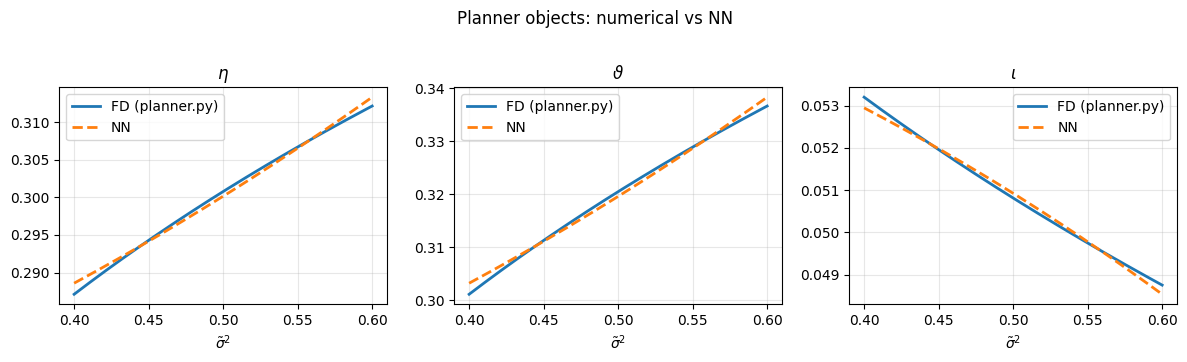

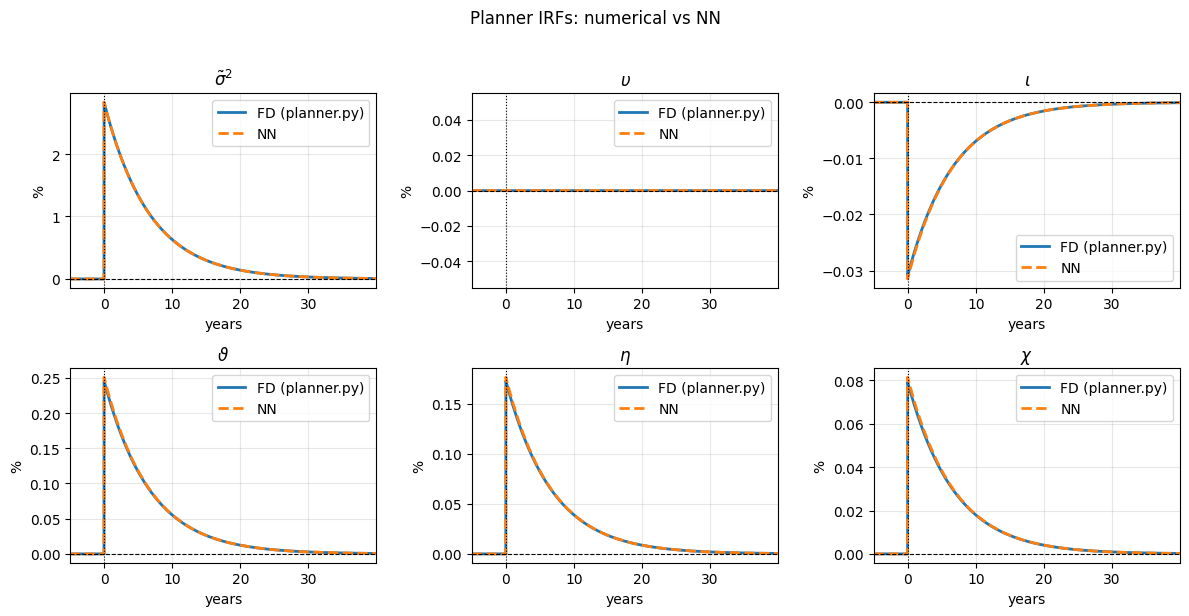

In [8]:
fd_params = PlannerParams(Nsp=Nsp, dZ=dZ, T_irf=T_irf, dt_irf=dt_irf, ap=ap)
fd = solve_planner(fd_params, make_irf=True)
print(
    f"[FD]  eta_ss={fd.etap_ss:.4f}, v_ss={fd.vp_ss:.4f}, u_ss={fd.up_ss:.4f}\n"
    f"[NN]  eta_ss={objs['eta_ss']:.4f}, v_ss={objs['theta_ss']:.4f}, u_ss={objs['u_ss']:.4f}"
)

fig, axs = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, (nn_key, fd_y, title) in zip(
    axs,
    [
        ("eta", fd.etap0, r"$\eta$"),
        ("theta", fd.vp0, r"$\vartheta$"),
        ("iota", fd.iotap0, r"$\iota$"),
    ],
):
    ax.plot(fd.sig2tp, fd_y, lw=2, label="FD (planner.py)")
    ax.plot(objs["sig2"], objs[nn_key], lw=2, ls="--", label="NN")
    ax.set_xlabel(r"$\tilde{\sigma}^2$")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle("Planner objects: numerical vs NN", y=1.02)
fig.tight_layout()
plt.show()

# Overlay impulse responses using the same shock, horizon, and time step.
irf_series = [
    ("path_sig", r"$\tilde{\sigma}^2$"),
    ("path_u", r"$\upsilon$"),
    ("path_iota", r"$\iota$"),
    ("path_v", r"$\vartheta$"),
    ("path_eta", r"$\eta$"),
    ("path_chi", r"$\chi$"),
]
fig, axs = plt.subplots(2, 3, figsize=(12, 6))
for ax, (key, title) in zip(axs.ravel(), irf_series):
    ax.plot(fd.path["time"], fd.path[key], lw=2, label="FD (planner.py)")
    ax.plot(irf["time"], irf[key], lw=2, ls="--", label="NN")
    ax.axhline(0.0, color="k", ls="--", lw=0.8)
    ax.axvline(0.0, color="k", ls=":", lw=0.8)
    ax.set_xlim(irf["time"][0], irf["time"][-1])
    ax.set_title(title)
    ax.set_ylabel("%")
    ax.set_xlabel("years")
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle("Planner IRFs: numerical vs NN", y=1.02)
fig.tight_layout()
plt.show()